In [27]:
import pandas as pd
from surprise import Reader, Dataset 
from surprise import SVD  
from surprise import accuracy 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Sistemas de Recomendación - Tu Futuro según la Data
Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

> - Objetivos
> - Explorar los datos del censo.
> - Construir perfiles socioeconómicos.
> - Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
> - Aplicar técnicas de sistemas de recomendación.
> - Visualizar y comunicar hallazgos de forma profesional.

Este dataset incluye variables como:

- Edad
- Nivel educativo
- Estado civil
- Ocupación
- Horas trabajadas por semana
- Sexo
- País de origen
- Ingreso anual (>50K o <=50K)

### EDA

In [28]:
df = pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/internal-link-proyecto13.csv')

In [29]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [30]:
df.drop(columns=['race', 'sex', 'capital.gain', 'capital.loss', 'native.country', 'workclass'], inplace=True)

Se eliminaron variables que podían introducir sesgos o ruido en el modelo, como race, sex y native.country. También se eliminaron capital.gain y capital.loss por tener muchos valores extremos, y workclass para simplificar el conjunto de datos. De esta forma se mantuvieron solo las variables más relevantes para el análisis.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   fnlwgt          32561 non-null  int64 
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   hours.per.week  32561 non-null  int64 
 8   income          32561 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.2+ MB


In [32]:
df.drop_duplicates(inplace=True)

In [33]:
(df == '?').sum()


age                  0
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
hours.per.week       0
income               0
dtype: int64

In [34]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

Se reemplazaron los valores "?" por valores nulos y posteriormente se eliminaron las filas incompletas para evitar sesgos en el modelo.

In [35]:
df['education'].value_counts(), df['education.num'].value_counts()

(education
 HS-grad         9957
 Some-college    6761
 Bachelors       5180
 Masters         1674
 Assoc-voc       1321
 11th            1056
 Assoc-acdm      1020
 10th             831
 7th-8th          572
 Prof-school      558
 9th              463
 Doctorate        398
 12th             393
 5th-6th          302
 1st-4th          154
 Preschool         45
 Name: count, dtype: int64,
 education.num
 9     9957
 10    6761
 13    5180
 14    1674
 11    1321
 7     1056
 12    1020
 6      831
 4      572
 15     558
 5      463
 16     398
 8      393
 3      302
 2      154
 1       45
 Name: count, dtype: int64)

In [36]:
len(df['education'])

30685

In [37]:
df['income'].value_counts()

income
<=50K    23039
>50K      7646
Name: count, dtype: int64

In [38]:
df_num = df.copy()

In [39]:
type(df_num)

pandas.core.frame.DataFrame

In [40]:
df_num.drop(columns=['education'])

,age,fnlwgt,education.num,marital.status,occupation,relationship,hours.per.week,income
1,82,132870,9,Widowed,Exec-managerial,Not-in-family,18,<=50K
3,54,140359,4,Divorced,Machine-op-inspct,Unmarried,40,<=50K
4,41,264663,10,Separated,Prof-specialty,Own-child,40,<=50K
5,34,216864,9,Divorced,Other-service,Unmarried,45,<=50K
6,38,150601,6,Separated,Adm-clerical,Unmarried,40,<=50K
...,...,...,...,...,...,...,...,...
32556,22,310152,10,Never-married,Protective-serv,Not-in-family,40,<=50K
32557,27,257302,12,Married-civ-spouse,Tech-support,Wife,38,<=50K
32558,40,154374,9,Married-civ-spouse,Machine-op-inspct,Husband,40,>50K
32559,58,151910,9,Widowed,Adm-clerical,Unmarried,40,<=50K


In [41]:
df_num ['number_marital.status'] = pd.factorize(df['marital.status'])[0]
df_num ['number_occupation'] = pd.factorize(df['occupation'])[0]
df_num ['number_relationship'] = pd.factorize(df['relationship'])[0]
df_num ['number_income'] = pd.factorize(df['income'])[0]
df_num_factorize = df_num.select_dtypes(include=['number'])

In [42]:
df_num_factorize

,age,fnlwgt,education.num,hours.per.week,number_marital.status,number_occupation,number_relationship,number_income
1,82,132870,9,18,0,0,0,0
3,54,140359,4,40,1,1,1,0
4,41,264663,10,40,2,2,2,0
5,34,216864,9,45,1,3,1,0
6,38,150601,6,40,2,4,1,0
...,...,...,...,...,...,...,...,...
32556,22,310152,10,40,3,11,0,0
32557,27,257302,12,38,4,10,5,0
32558,40,154374,9,40,4,1,4,1
32559,58,151910,9,40,0,4,1,0


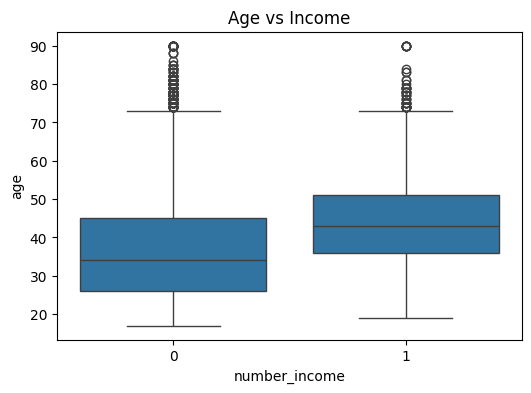

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x="number_income", y="age", data=df_num_factorize)
plt.title("Age vs Income")
plt.show()

El boxplot muestra que las personas con ingresos superiores a 50K presentan una edad media y mediana más elevada que aquellas con ingresos menores o iguales a 50K. Esto indica que la edad es una variable relevante para la predicción del nivel de ingresos.

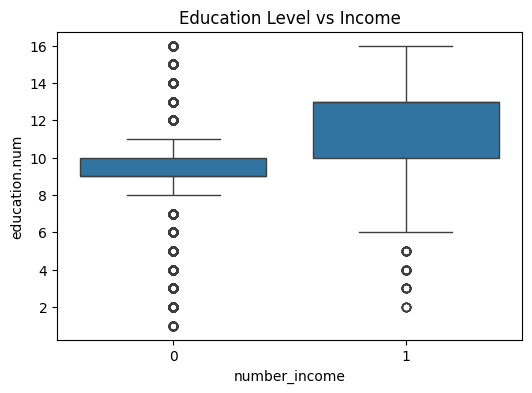

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x="number_income", y="education.num", data=df_num_factorize)
plt.title("Education Level vs Income")
plt.show()

In [45]:
df.groupby("education")["income"].value_counts(normalize=True)

education     income
10th          <=50K     0.927798
              >50K      0.072202
11th          <=50K     0.943182
              >50K      0.056818
12th          <=50K     0.921120
              >50K      0.078880
1st-4th       <=50K     0.961039
              >50K      0.038961
5th-6th       <=50K     0.953642
              >50K      0.046358
7th-8th       <=50K     0.933566
              >50K      0.066434
9th           <=50K     0.943844
              >50K      0.056156
Assoc-acdm    <=50K     0.746078
              >50K      0.253922
Assoc-voc     <=50K     0.736563
              >50K      0.263437
Bachelors     <=50K     0.579923
              >50K      0.420077
Doctorate     >50K      0.741206
              <=50K     0.258794
HS-grad       <=50K     0.836597
              >50K      0.163403
Masters       >50K      0.562127
              <=50K     0.437873
Preschool     <=50K     1.000000
Prof-school   >50K      0.743728
              <=50K     0.256272
Some-college  <=50K   

Se observa que niveles educativos más altos y determinadas ocupaciones presentan una mayor proporción de ingresos superiores a 50K.

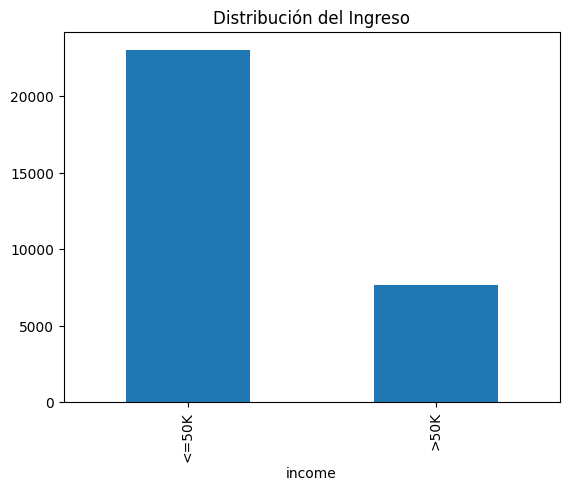

In [46]:
df["income"].value_counts().plot(kind="bar")
plt.title("Distribución del Ingreso")
plt.show()

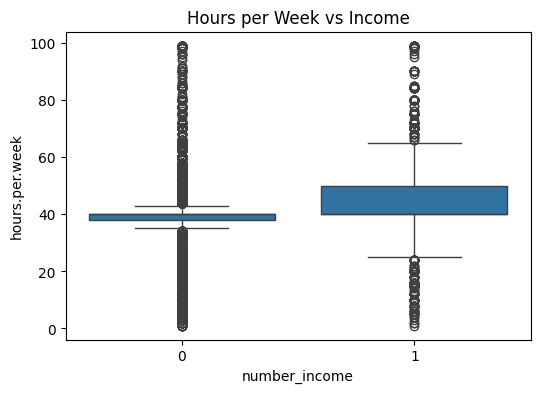

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x="number_income", y="hours.per.week", data=df_num_factorize)
plt.title("Hours per Week vs Income")
plt.show()

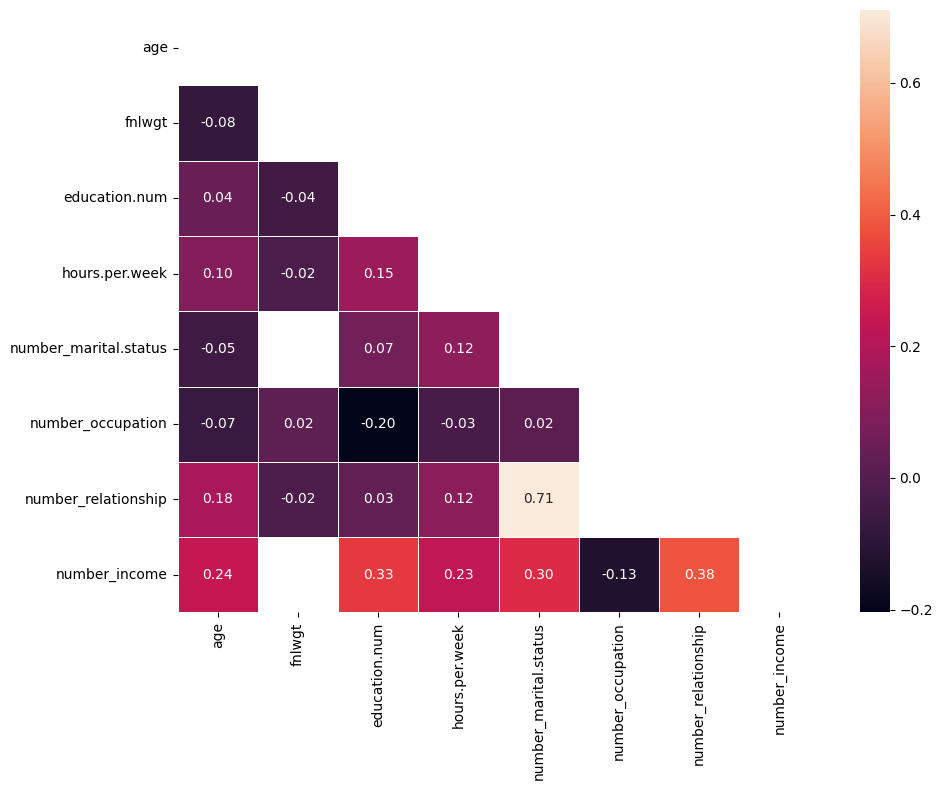

In [48]:
corr = df_num_factorize.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.01]
significant_corr
fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

## Hallazgos del Análisis Exploratorio

- El nivel educativo muestra una fuerte relación con el ingreso.
- Las personas que trabajan más horas tienden a superar el umbral de 50K.
- La edad también influye positivamente en el ingreso.
- Determinadas ocupaciones presentan mayor proporción de ingresos altos.
- Se observa un desbalance en la variable objetivo.

In [49]:
X = df.drop("income", axis=1)
y = df["income"]

In [50]:
y = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18, stratify=y)

X_train.head()

,age,fnlwgt,education,education.num,marital.status,occupation,relationship,hours.per.week
9336,28,161607,Some-college,10,Married-civ-spouse,Transport-moving,Husband,45
3096,58,250206,10th,6,Married-civ-spouse,Craft-repair,Husband,40
2230,63,298249,Bachelors,13,Married-civ-spouse,Sales,Husband,40
26552,22,222993,HS-grad,9,Never-married,Prof-specialty,Own-child,54
28185,31,111883,HS-grad,9,Never-married,Craft-repair,Other-relative,40


In [52]:
eda_adult = pd.DataFrame(df)
eda_adult.to_csv("../data/processed/eda_adult_income.csv", index=False)